In [74]:
# Gustavo Cruz 22779
# Javier Chen 22153

# Imports
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from pathlib import Path
import openeo
import folium
import numpy as np
import rasterio
from rasterio.plot import reshape_as_image
import tempfile
from PIL import Image
import io
import base64
import ipywidgets as widgets
from IPython.display import display, clear_output

In [50]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


In [51]:
# Arriba hay que autenticar con el url que te da el notebook, se ingresan las credenciales y se cierra la pestaña cuando termines

# Ejercicio 2

with open("data/Lago_Amatitlan.geojson", "r", encoding="utf-8") as f:
    amatitlan_geo = json.load(f)

with open("data/Lago_Atitlan.geojson", "r", encoding="utf-8") as f:
    atitlan_geo = json.load(f)

def geojson_to_bbox(geojson):
    coords = geojson["features"][0]["geometry"]["coordinates"][0]
    longs = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    return {
        "west": min(longs),
        "east": max(longs),
        "south": min(lats),
        "north": max(lats)
    }

bbox_amatitlan = geojson_to_bbox(amatitlan_geo)
bbox_atitlan = geojson_to_bbox(atitlan_geo)

print("bbox_amatitlan:", bbox_amatitlan)
print("bbox_atitlan:", bbox_atitlan)

# Ejercicio 3
START_DATE = "2025-01-01" 
END_DATE = "2025-08-01"

bbox_amatitlan: {'west': -90.638065, 'east': -90.512924, 'south': 14.412347, 'north': 14.493799}
bbox_atitlan: {'west': -91.326256, 'east': -91.07151, 'south': 14.5948, 'north': 14.750979}


In [52]:
# Ejercicio 4 y 5
def load_cube(bbox):
    cube = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=bbox,
        temporal_extent=[START_DATE, END_DATE],
        bands=["B02", "B03", "B04", "B08"]
    )
    
    # Filtrar para obtener máximo 4 imágenes por mes
    filtered_cube = cube.aggregate_temporal_period(
        period="month",
        reducer="first"
    ).filter_temporal([START_DATE, END_DATE])
    
    return filtered_cube

def ndci(cube):
    b5 = cube.band("B05")
    b4 = cube.band("B04")
    return (b5 - b4) / (b5 + b4)

def process_and_download_ndci(bbox, out_folder):
    print(f"Procesando {out_folder}...")
    cube = load_cube(bbox)
    
    os.makedirs(out_folder, exist_ok=True)
    result = cube.save_result(format="GTIFF")
    job = connection.create_job(result)
    job.start_and_wait()
    job.get_results().download_files(out_folder)
    print(f"Descarga completada en {out_folder}")
    return out_folder

cube = load_cube(bbox_amatitlan)
print(cube.metadata)

# Ejecutar para ambos lagos
process_and_download_ndci(bbox_amatitlan, "./imagenes/NDCI_Amatitlan")
process_and_download_ndci(bbox_atitlan, "./imagenes/NDCI_Atitlan")


# Estas van a ser funciones auxiliares para presentar mejor la data despues
def parse_date_from_name(name):
    m = re.search(r"openEO_(\d{4}-\d{2}-\d{2})Z", name)
    return m.group(1) if m else None

def compute_index(num, den):
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(den == 0, np.nan, num / den)

def normalize_if_needed(x):
    x = x.astype(np.float32)
    return x / 10000.0 if np.nanmax(x) > 2 else x

def download_cube(cube, folder):
    os.makedirs(folder, exist_ok=True)
    result = cube.save_result(format="GTIFF")
    job = connection.create_job(result)
    job.start_and_wait()
    job.get_results().download_files(folder)
    return folder

# Como tarda un monton, ahorita solo descarga 1 imagen por mes, para aumentarla se puede modificar la funcion de load_cube

CollectionMetadata({'spatial': {'bbox': [[-180, -56, 180, 83]]}, 'temporal': {'interval': [['2015-07-04T00:00:00Z', None]]}} - ['B02', 'B03', 'B04', 'B08'] - ['bands', 't', 'x', 'y'])
Procesando ./imagenes/NDCI_Amatitlan...
0:00:00 Job 'j-2508102145264032818ab756fe15628c': send 'start'
0:00:13 Job 'j-2508102145264032818ab756fe15628c': created (progress 0%)
0:00:18 Job 'j-2508102145264032818ab756fe15628c': created (progress 0%)
0:00:25 Job 'j-2508102145264032818ab756fe15628c': created (progress 0%)
0:00:33 Job 'j-2508102145264032818ab756fe15628c': created (progress 0%)
0:00:43 Job 'j-2508102145264032818ab756fe15628c': running (progress N/A)
0:00:56 Job 'j-2508102145264032818ab756fe15628c': running (progress N/A)
0:01:11 Job 'j-2508102145264032818ab756fe15628c': running (progress N/A)
0:01:30 Job 'j-2508102145264032818ab756fe15628c': running (progress N/A)
0:01:55 Job 'j-2508102145264032818ab756fe15628c': running (progress N/A)
0:02:25 Job 'j-2508102145264032818ab756fe15628c': running (p

=== ÍNDICES PROMEDIO DE CIANOBACTERIAS ===

Lago Atitlán:
                mean       std  max  min
date                                    
2025-01-01  0.124395  0.194207  1.0 -1.0
2025-02-01  0.102402  0.207486  1.0 -1.0
2025-03-01  0.030008  0.137855  1.0 -1.0
2025-04-01  0.033237  0.158194  1.0 -1.0
2025-05-01 -0.004774  0.104523  1.0 -1.0
2025-06-01 -0.010854  0.111842  1.0 -1.0
2025-07-01  0.062307  0.159343  1.0 -1.0

Lago Amatitlán:
                mean       std       max       min
date                                              
2025-01-01  0.129143  0.161726  1.000000 -1.000000
2025-02-01  0.167267  0.130169  1.000000 -1.000000
2025-03-01  0.072307  0.134370  1.000000 -1.000000
2025-04-01  0.120135  0.100676  1.000000 -1.000000
2025-05-01  0.029860  0.063201  0.453039 -0.480487
2025-06-01  0.020661  0.050331  0.235374 -0.335367
2025-07-01  0.090117  0.149371  1.000000 -1.000000


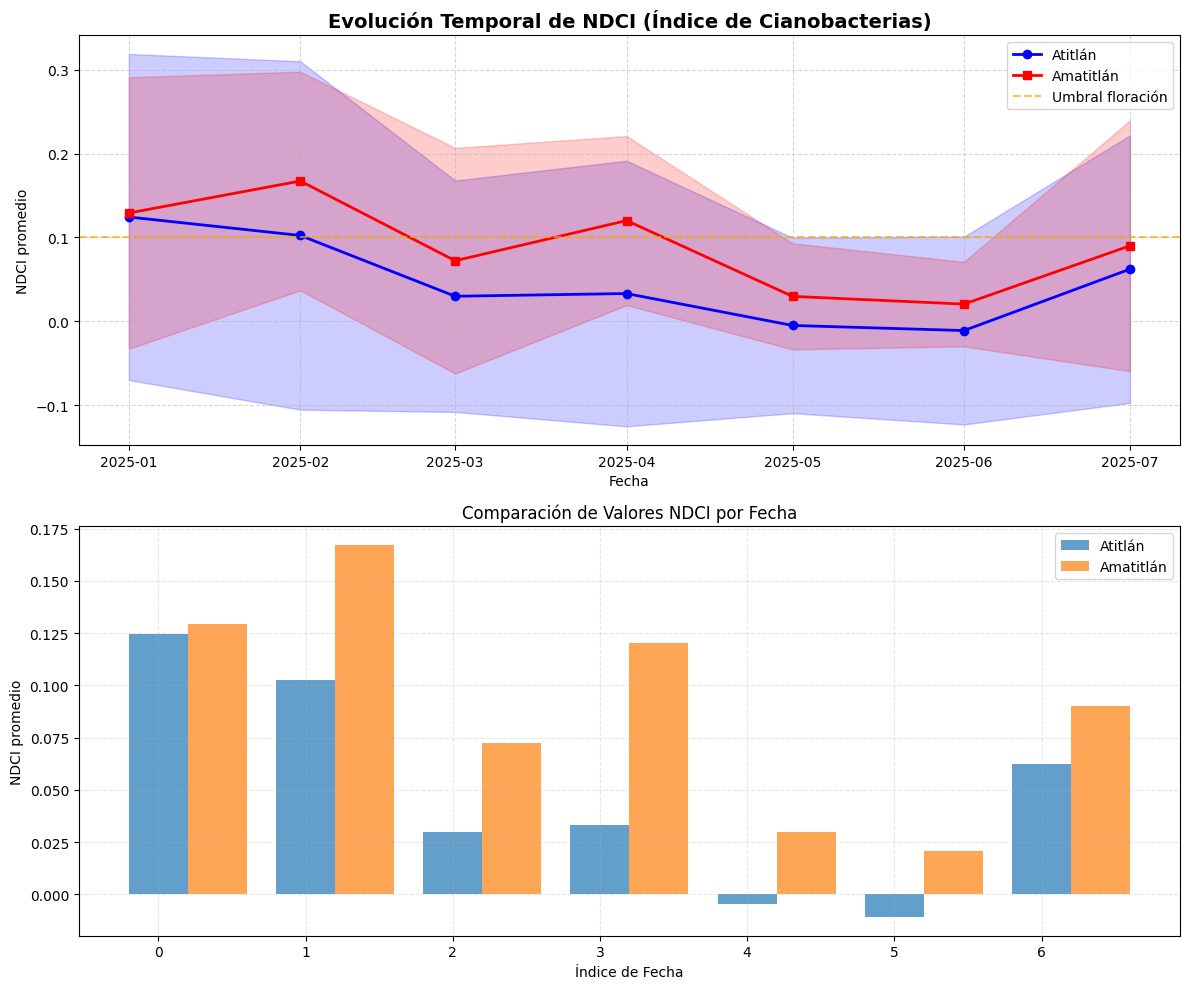


=== ANÁLISIS DE FLORACIONES - Atitlán ===
Fechas con posible floración de cianobacterias (NDCI > 0.1):
  - 2025-01-01: NDCI = 0.1244
  - 2025-02-01: NDCI = 0.1024

PICO MÁXIMO de floración:
  Fecha: 2025-01-01
  Valor NDCI: 0.1244

Estadísticas generales:
  NDCI promedio: 0.0481
  NDCI máximo: 0.1244
  NDCI mínimo: -0.0109
  Desviación estándar: 0.0513

=== ANÁLISIS DE FLORACIONES - Amatitlán ===
Fechas con posible floración de cianobacterias (NDCI > 0.1):
  - 2025-01-01: NDCI = 0.1291
  - 2025-02-01: NDCI = 0.1673
  - 2025-04-01: NDCI = 0.1201

PICO MÁXIMO de floración:
  Fecha: 2025-02-01
  Valor NDCI: 0.1673

Estadísticas generales:
  NDCI promedio: 0.0899
  NDCI máximo: 0.1673
  NDCI mínimo: 0.0207
  Desviación estándar: 0.0535


In [82]:
def process_tif_folder(folder):
    """Procesa todos los archivos TIF de una carpeta y calcula índices."""
    ndci_data = {}
    ndvi_data = {}
    ndwi_data = {}
    
    for tif_path in Path(folder).glob("*.tif"):
        date = parse_date_from_name(tif_path.name)
        if not date:
            continue
            
        with rasterio.open(tif_path) as src:
            red = normalize_if_needed(src.read(1))
            b5 = normalize_if_needed(src.read(2))
            green = normalize_if_needed(src.read(3))
            nir = normalize_if_needed(src.read(4))
            
            # Cálculo de índices
            ndci_val = compute_index(b5 - red, b5 + red)
            ndvi_val = compute_index(nir - red, nir + red)
            ndwi_val = compute_index(green - nir, green + nir)
            
            ndci_data[date] = ndci_val
            ndvi_data[date] = ndvi_val
            ndwi_data[date] = ndwi_val
            
    return ndci_data, ndvi_data, ndwi_data

# Procesar datos de ambos lagos
ndci_atl, ndvi_atl, ndwi_atl = process_tif_folder("./imagenes/NDCI_Atitlan")
ndci_ama, ndvi_ama, ndwi_ama = process_tif_folder("./imagenes/NDCI_Amatitlan")

# 6.1. Calcular índice promedio de cianobacteria por lago y por fecha
def mean_by_date(index_dict):
    """Calcula la media del índice por fecha."""
    rows = []
    for d, arr in index_dict.items():
        arr_clip = np.clip(arr, -1.0, 1.0)
        # Filtrar valores válidos (dentro del rango típico de cianobacterias)
        valid_mask = ~np.isnan(arr_clip)
        if np.any(valid_mask):
            mean_val = np.nanmean(arr_clip[valid_mask])
            rows.append({
                "date": pd.to_datetime(d), 
                "mean": mean_val,
                "std": np.nanstd(arr_clip[valid_mask]),
                "max": np.nanmax(arr_clip[valid_mask]),
                "min": np.nanmin(arr_clip[valid_mask])
            })
    return pd.DataFrame(rows).sort_values("date").set_index("date")

# Crear series temporales para ambos lagos
ndci_atl_series = mean_by_date(ndci_atl)
ndci_ama_series = mean_by_date(ndci_ama)

print("=== ÍNDICES PROMEDIO DE CIANOBACTERIAS ===")
print("\nLago Atitlán:")
print(ndci_atl_series)
print("\nLago Amatitlán:")
print(ndci_ama_series)

# 6.2. Visualizar evolución temporal en gráfico de línea por lago
def plot_temporal_evolution():
    """Crea gráfico de evolución temporal mejorado."""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Gráfico principal con ambos lagos
    ax1.plot(ndci_atl_series.index, ndci_atl_series["mean"], 
             marker="o", linewidth=2, label="Atitlán", color='blue')
    ax1.fill_between(ndci_atl_series.index, 
                     ndci_atl_series["mean"] - ndci_atl_series["std"],
                     ndci_atl_series["mean"] + ndci_atl_series["std"],
                     alpha=0.2, color='blue')
    
    ax1.plot(ndci_ama_series.index, ndci_ama_series["mean"], 
             marker="s", linewidth=2, label="Amatitlán", color='red')
    ax1.fill_between(ndci_ama_series.index, 
                     ndci_ama_series["mean"] - ndci_ama_series["std"],
                     ndci_ama_series["mean"] + ndci_ama_series["std"],
                     alpha=0.2, color='red')
    
    ax1.set_title("Evolución Temporal de NDCI (Índice de Cianobacterias)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Fecha")
    ax1.set_ylabel("NDCI promedio")
    ax1.legend()
    ax1.grid(True, linestyle="--", alpha=0.5)
    
    # Línea de referencia para floración (NDCI > 0.1 indica posible floración)
    ax1.axhline(y=0.1, color='orange', linestyle='--', alpha=0.7, label='Umbral floración')
    ax1.legend()
    
    # Gráfico de comparación directa
    ax2.bar(range(len(ndci_atl_series)), ndci_atl_series["mean"], 
            alpha=0.7, label="Atitlán", width=0.4)
    ax2.bar([x + 0.4 for x in range(len(ndci_ama_series))], ndci_ama_series["mean"], 
            alpha=0.7, label="Amatitlán", width=0.4)
    
    ax2.set_title("Comparación de Valores NDCI por Fecha")
    ax2.set_xlabel("Índice de Fecha")
    ax2.set_ylabel("NDCI promedio")
    ax2.legend()
    ax2.grid(True, linestyle="--", alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("./imagenes/ndci_evolucion_completa.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_temporal_evolution()

# 6.3. Identificar picos de floración y fechas críticas
def identify_bloom_peaks(series, lago_name, threshold=0.1):
    """Identifica picos de floración y fechas críticas."""
    print(f"\n=== ANÁLISIS DE FLORACIONES - {lago_name} ===")
    
    # Identificar floraciones (NDCI > threshold)
    blooms = series[series["mean"] > threshold]
    
    if len(blooms) > 0:
        print(f"Fechas con posible floración de cianobacterias (NDCI > {threshold}):")
        for date, row in blooms.iterrows():
            print(f"  - {date.strftime('%Y-%m-%d')}: NDCI = {row['mean']:.4f}")
        
        # Pico máximo
        max_bloom = blooms.loc[blooms["mean"].idxmax()]
        print(f"\nPICO MÁXIMO de floración:")
        print(f"  Fecha: {blooms['mean'].idxmax().strftime('%Y-%m-%d')}")
        print(f"  Valor NDCI: {max_bloom['mean']:.4f}")
        
    else:
        print(f"No se detectaron floraciones significativas (NDCI > {threshold})")
    
    # Estadísticas generales
    print(f"\nEstadísticas generales:")
    print(f"  NDCI promedio: {series['mean'].mean():.4f}")
    print(f"  NDCI máximo: {series['mean'].max():.4f}")
    print(f"  NDCI mínimo: {series['mean'].min():.4f}")
    print(f"  Desviación estándar: {series['mean'].std():.4f}")
    
    return blooms

# Analizar picos para ambos lagos
blooms_atl = identify_bloom_peaks(ndci_atl_series, "Atitlán")
blooms_ama = identify_bloom_peaks(ndci_ama_series, "Amatitlán")

In [85]:
with open("data/Lago_Amatitlan.geojson", "r", encoding="utf-8") as f:
    amatitlan_geo = json.load(f)

with open("data/Lago_Atitlan.geojson", "r", encoding="utf-8") as f:
    atitlan_geo = json.load(f)

def geojson_to_bbox(geojson):
    coords = geojson["features"][0]["geometry"]["coordinates"][0]
    longs = [c[0] for c in coords]
    lats = [c[1] for c in coords]
    return {
        "west": min(longs),
        "east": max(longs),
        "south": min(lats),
        "north": max(lats)
    }

bbox_amatitlan = geojson_to_bbox(amatitlan_geo)
bbox_atitlan = geojson_to_bbox(atitlan_geo)

# 7.1. Mapear distribución de cianobacterias 
def crear_mapa_interactivo_con_geojson(ndci_array, bbox, geojson_obj, titulo="NDCI", opacity=0.7):
    # Centro del mapa
    lat_centro = (bbox["north"] + bbox["south"]) / 2
    lon_centro = (bbox["east"] + bbox["west"]) / 2
    
    # Crear mapa base
    m = folium.Map(
        location=[lat_centro, lon_centro], 
        zoom_start=12,
        tiles='OpenStreetMap'
    )
    
    folium.TileLayer('Stamen Terrain').add_to(m)
    folium.TileLayer('CartoDB positron').add_to(m)
    
    # Normalización del array NDCI
    valid_data = ndci_array[~np.isnan(ndci_array)]
    if len(valid_data) == 0:
        print("Advertencia: No hay datos válidos para mostrar")
        return m
    
    vmin, vmax = np.percentile(valid_data, [5, 95])  # Usar percentiles 
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    
    # Colormap específico para cianobacterias (azul-verde-amarillo-rojo)
    colormap = plt.colormaps.get_cmap('RdYlBu_r')  # Invertido para que rojo=alta concentración
    
    # Convertir array a imagen RGBA
    img_normalized = norm(ndci_array)
    img_colored = colormap(img_normalized)
    img_rgba = (img_colored * 255).astype(np.uint8)
    
    # Crear imagen PIL
    pil_img = Image.fromarray(img_rgba, mode='RGBA')
    
    # Codificar en base64
    buffered = io.BytesIO()
    pil_img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode()
    img_url = f"data:image/png;base64,{img_str}"
    
    #  overlay del ráster
    folium.raster_layers.ImageOverlay(
        image=img_url,
        bounds=[[bbox["south"], bbox["west"]], [bbox["north"], bbox["east"]]],
        opacity=opacity,
        name=f"NDCI - {titulo}"
    ).add_to(m)
    
    #  contorno del lago
    folium.GeoJson(
        geojson_obj,
        name="Límite del lago",
        style_function=lambda feature: {
            'fillColor': 'transparent',
            'color': 'navy',
            'weight': 3,
            'opacity': 0.8,
            'fillOpacity': 0
        }
    ).add_to(m)
    
    #  colorbar/leyenda como HTML personalizado
    colorbar_html = f"""
    <div style="position: fixed; 
                top: 10px; right: 10px; width: 200px; height: 90px; 
                background-color: white; border:2px solid grey; z-index:9999; 
                font-size:14px; padding: 10px">
    <p><b>{titulo}</b></p>
    <p style="color: red;">Alto: {vmax:.3f}</p>
    <p style="color: blue;">Bajo: {vmin:.3f}</p>
    </div>
    """
    m.get_root().html.add_child(folium.Element(colorbar_html))
    
    folium.LayerControl().add_to(m)
    
    return m

# 7.2.  mapas comparativos entre diferentes fechas
def crear_mapas_comparativos():
    lagos_config = {
        "Atitlán": {
            "ndci": ndci_atl,
            "bbox": bbox_atitlan,
            "geojson": atitlan_geo,
        },
        "Amatitlán": {
            "ndci": ndci_ama,
            "bbox": bbox_amatitlan,
            "geojson": amatitlan_geo,
        },
    }
    
    mapas_generados = {}
    
    for lago_nombre, config in lagos_config.items():
        print(f"\nMapa de: {lago_nombre} ===")
        fechas_disponibles = sorted(list(config["ndci"].keys()))
        
        # Seleccionar fechas representativas (primera, media, última)
        if len(fechas_disponibles) >= 6:
            fechas_seleccionadas = [
                fechas_disponibles[0],  # Primera
                fechas_disponibles[len(fechas_disponibles)//2],  # Media
                fechas_disponibles[-1]  # Última
            ]
        else:
            fechas_seleccionadas = fechas_disponibles
        
        mapas_lago = {}
        
        for fecha in fechas_seleccionadas:
            print(f" fecha: {fecha}")
            ndci_array = config["ndci"][fecha]
            
            titulo = f"{lago_nombre} - {pd.to_datetime(fecha).strftime('%Y-%m-%d')}"
            mapa = crear_mapa_interactivo_con_geojson(
                ndci_array=ndci_array,
                bbox=config["bbox"],
                geojson_obj=config["geojson"],
                titulo=titulo
            )
            
            mapas_lago[fecha] = mapa
        
        mapas_generados[lago_nombre] = mapas_lago
    
    return mapas_generados

# Generar mapas comparativos
mapas_comparativos = crear_mapas_comparativos()

# Interfaz interactiva mejorada con widgets
def crear_interfaz_interactiva():
    
    lagos_config = {
        "Atitlán": {
            "ndci": ndci_atl,
            "bbox": bbox_atitlan,
            "geojson": atitlan_geo,
        },
        "Amatitlán": {
            "ndci": ndci_ama,
            "bbox": bbox_amatitlan,
            "geojson": amatitlan_geo,
        },
    }
    
    # Widgets
    lago_selector = widgets.Dropdown(
        options=list(lagos_config.keys()), 
        description="Lago:",
        style={'description_width': 'initial'}
    )
    
    # Inicializar fechas con el primer lago
    fechas_iniciales = sorted(list(lagos_config[lago_selector.value]["ndci"].keys()))
    fecha_selector = widgets.Dropdown(
        options=[(pd.to_datetime(f).strftime('%Y-%m-%d'), f) for f in fechas_iniciales],
        description="Fecha:",
        style={'description_width': 'initial'}
    )
    
    # Widget para opacidad
    opacity_slider = widgets.FloatSlider(
        value=0.7,
        min=0.1,
        max=1.0,
        step=0.1,
        description='Opacidad:',
        style={'description_width': 'initial'}
    )
    
    # Función para actualizar fechas cuando cambia lago
    def on_lago_change(change):
        nuevo_lago = change['new']
        fechas = sorted(list(lagos_config[nuevo_lago]["ndci"].keys()))
        fecha_selector.options = [(pd.to_datetime(f).strftime('%Y-%m-%d'), f) for f in fechas]
        if fechas:
            fecha_selector.value = fechas[0]
    
    lago_selector.observe(on_lago_change, names='value')
    
    # Área de salida para el mapa
    output_map = widgets.Output()
    
    def mostrar_mapa(lago, fecha, opacity):
        with output_map:
            clear_output(wait=True)
            
            try:
                config = lagos_config[lago]
                ndci_array = config["ndci"][fecha]
                
                titulo = f"{lago} - {pd.to_datetime(fecha).strftime('%Y-%m-%d')}"
                mapa = crear_mapa_interactivo_con_geojson(
                    ndci_array=ndci_array,
                    bbox=config["bbox"],
                    geojson_obj=config["geojson"],
                    titulo=titulo,
                    opacity=opacity
                )
                
                print(f"Mapa generado para {titulo}")
                print(f"Estadísticas NDCI:")
                print(f"  Media: {np.nanmean(ndci_array):.4f}")
                print(f"  Máximo: {np.nanmax(ndci_array):.4f}")
                print(f"  Mínimo: {np.nanmin(ndci_array):.4f}")
                
                display(mapa)
                
            except Exception as e:
                print(f"Error generando mapa: {str(e)}")
    
    # Función que se ejecuta cuando cambian los controles
    def on_change(change):
        mostrar_mapa(lago_selector.value, fecha_selector.value, opacity_slider.value)
    
    # Vincular eventos
    lago_selector.observe(on_change, names='value')
    fecha_selector.observe(on_change, names='value')
    opacity_slider.observe(on_change, names='value')
    
    # Layout de la interfaz
    controles = widgets.HBox([lago_selector, fecha_selector, opacity_slider])
    interfaz = widgets.VBox([
        widgets.HTML("<h3>Explorador Interactivo de Distribución de Cianobacterias</h3>"),
        controles, 
        output_map
    ])
    
    # Mostrar interfaz
    display(interfaz)
    
    # Mostrar mapa inicial
    mostrar_mapa(lago_selector.value, fecha_selector.value, opacity_slider.value)
    
    return interfaz

# Crear y mostrar la interfaz interactiva
print("INTERFAZ INTERACTIVA")

interfaz = crear_interfaz_interactiva()




Mapa de: Atitlán ===
 fecha: 2025-01-01
 fecha: 2025-04-01
 fecha: 2025-07-01

Mapa de: Amatitlán ===
 fecha: 2025-01-01
 fecha: 2025-04-01
 fecha: 2025-07-01
INTERFAZ INTERACTIVA


In [79]:


# Ejercicio 8
def correlation_analysis(index1, index2):
    vals1 = []
    vals2 = []
    for d in index1:
        if d in index2:
            vals1.append(np.nanmean(index1[d]))
            vals2.append(np.nanmean(index2[d]))
    return np.corrcoef(vals1, vals2)[0, 1]

corr_atl_ndvi = correlation_analysis(ndci_atl, ndvi_atl)
corr_atl_ndwi = correlation_analysis(ndci_atl, ndwi_atl)
corr_ama_ndvi = correlation_analysis(ndci_ama, ndvi_ama)
corr_ama_ndwi = correlation_analysis(ndci_ama, ndwi_ama)

print("Correlación Atitlán NDCI-NDVI:", corr_atl_ndvi)
print("Correlación Atitlán NDCI-NDWI:", corr_atl_ndwi)
print("Correlación Amatitlán NDCI-NDVI:", corr_ama_ndvi)
print("Correlación Amatitlán NDCI-NDWI:", corr_ama_ndwi)



Correlación Atitlán NDCI-NDVI: 0.8959395268402536
Correlación Atitlán NDCI-NDWI: -0.9837244234954823
Correlación Amatitlán NDCI-NDVI: 0.9487929892909243
Correlación Amatitlán NDCI-NDWI: -0.8802192978140633
